In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns


train = pd.read_csv('C:/Users/hanan/Downloads/open (1)/train.csv')
test = pd.read_csv('C:/Users/hanan/Downloads/open (1)/test.csv')
sub = pd.read_csv('../../datafile/dacon/smart_manu_delay/sample_submission.csv')
layout = pd.read_csv('../../datafile/dacon/smart_manu_delay/layout_info.csv')

In [ ]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns


train = pd.read_csv('C:/Users/한승원/Downloads/open (1)/train.csv')
test = pd.read_csv('C:/Users/한승원/Downloads/open (1)/test.csv')
sub = pd.read_csv('../../datafile/dacon/smart_manu_delay/sample_submission.csv')
layout = pd.read_csv('../../datafile/dacon/smart_manu_delay/layout_info.csv')

In [2]:
train

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,2.50,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,NaN,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TRAIN_249995,WH_174,SC_05114,39.0,NaN,2.28,0.0513,0.1795,NaN,NaN,...,8.10,0.2586,4.17,0.0856,16.0,9.47,99.0,NaN,4.47,97.13
249996,TRAIN_249996,WH_174,SC_05114,69.0,96.0,2.22,0.0870,0.2319,0.0290,0.2226,...,8.63,0.2783,5.61,0.0526,19.6,11.41,NaN,0.0438,NaN,96.73
249997,TRAIN_249997,WH_174,SC_05114,61.0,123.0,2.62,0.0984,0.3934,0.0820,0.2226,...,NaN,0.2659,4.94,0.0379,16.5,13.26,95.9,NaN,3.24,98.86
249998,TRAIN_249998,WH_174,SC_05114,54.0,97.0,2.65,0.1296,0.1667,0.0185,0.2226,...,9.39,0.1736,4.40,0.0320,20.2,11.04,98.7,0.0519,1.97,98.63


In [5]:
train['avg_delay_minutes_next_30m']

0         5.554758
1         5.039834
2         5.920881
3         5.540926
4         3.940071
            ...   
249995    3.750256
249996    6.012434
249997    3.016485
249998    4.839744
249999    2.663544
Name: avg_delay_minutes_next_30m, Length: 250000, dtype: float64

In [6]:
layout.head()

,layout_id,layout_type,aisle_width_avg,intersection_count,one_way_ratio,pack_station_count,charger_count,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count
0,WH_001,narrow,2.08,34.0,0.3874,9.0,8.0,0.8078,0.5867,21,20,3384,9.4,36,5
1,WH_002,grid,3.70,16.0,0.0054,9.0,11.0,0.7339,0.4390,57,26,8311,8.1,12,2
2,WH_003,grid,2.54,52.0,0.0229,5.0,3.0,0.5498,0.3708,63,39,9465,7.2,81,2
3,WH_004,hybrid,3.37,35.0,0.4836,5.0,10.0,0.4821,0.5661,100,40,7918,12.7,26,5
4,WH_005,grid,3.68,48.0,0.0494,8.0,13.0,0.6740,0.9970,50,33,5905,5.6,84,9


## 1. EDA

In [16]:
train['avg_delay_minutes_next_30m']

0         5.554758
1         5.039834
2         5.920881
3         5.540926
4         3.940071
            ...   
249995    3.750256
249996    6.012434
249997    3.016485
249998    4.839744
249999    2.663544
Name: avg_delay_minutes_next_30m, Length: 250000, dtype: float64

In [20]:
a = train.corr(numeric_only=True)['avg_delay_minutes_next_30m']

In [ ]:
np.abs(a).sort_values(ascending=False)

avg_delay_minutes_next_30m    1.000000
low_battery_ratio             0.366073
battery_mean                  0.358886
robot_idle                    0.349311
order_inflow_15m              0.341754
robot_charging                0.320406
max_zone_density              0.310816
battery_std                   0.308313
congestion_score              0.300357
sku_concentration             0.291888
urgent_order_ratio            0.271079
charge_queue_length           0.261425
avg_charge_wait               0.251458
near_collision_15m            0.242848
unique_sku_15m                0.229013
blocked_path_15m              0.220499
loading_dock_util             0.213132
robot_utilization             0.210818
heavy_item_ratio              0.210314
fault_count_15m               0.202893
maintenance_schedule_score    0.196758
manual_override_ratio         0.196444
prev_shift_volume             0.188695
cold_chain_ratio              0.188085
avg_idle_duration_min         0.186248
avg_recovery_time        

<Axes: >

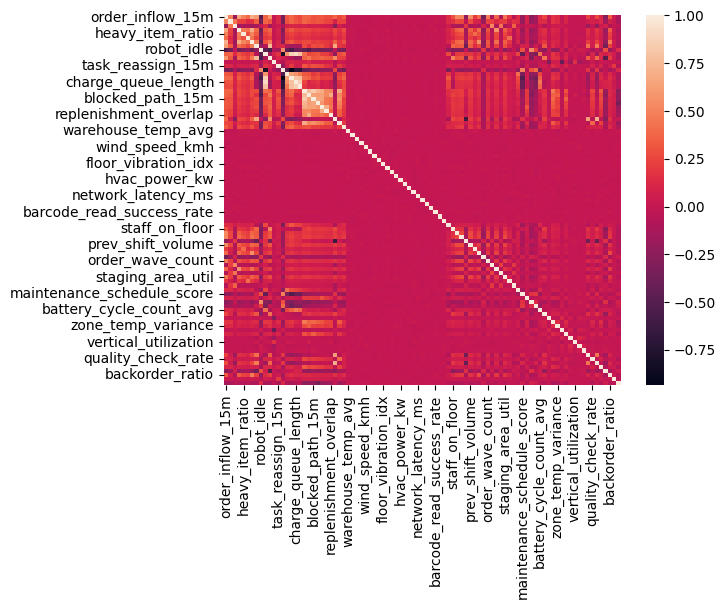

In [13]:
sns.heatmap(train.corr(numeric_only=True))